# 06 — Summary Figures

Produces publication-quality composite figures from the results of notebooks 02–05.

All figures are saved to `../figures/`.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from umap import UMAP
from pathlib import Path

tml_palette = sns.color_palette("tab20", 33)

DATA = Path("../data")
FIGURES = Path("../figures")
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 150

In [2]:
immune = pd.read_parquet(DATA / "sample_immune_labels.parquet")
senes  = pd.read_parquet(DATA / "sample_senescence.parquet")
master = immune.join(senes, how="inner")

## Figure 1: Pan-cancer CDKN2A expression heatmap

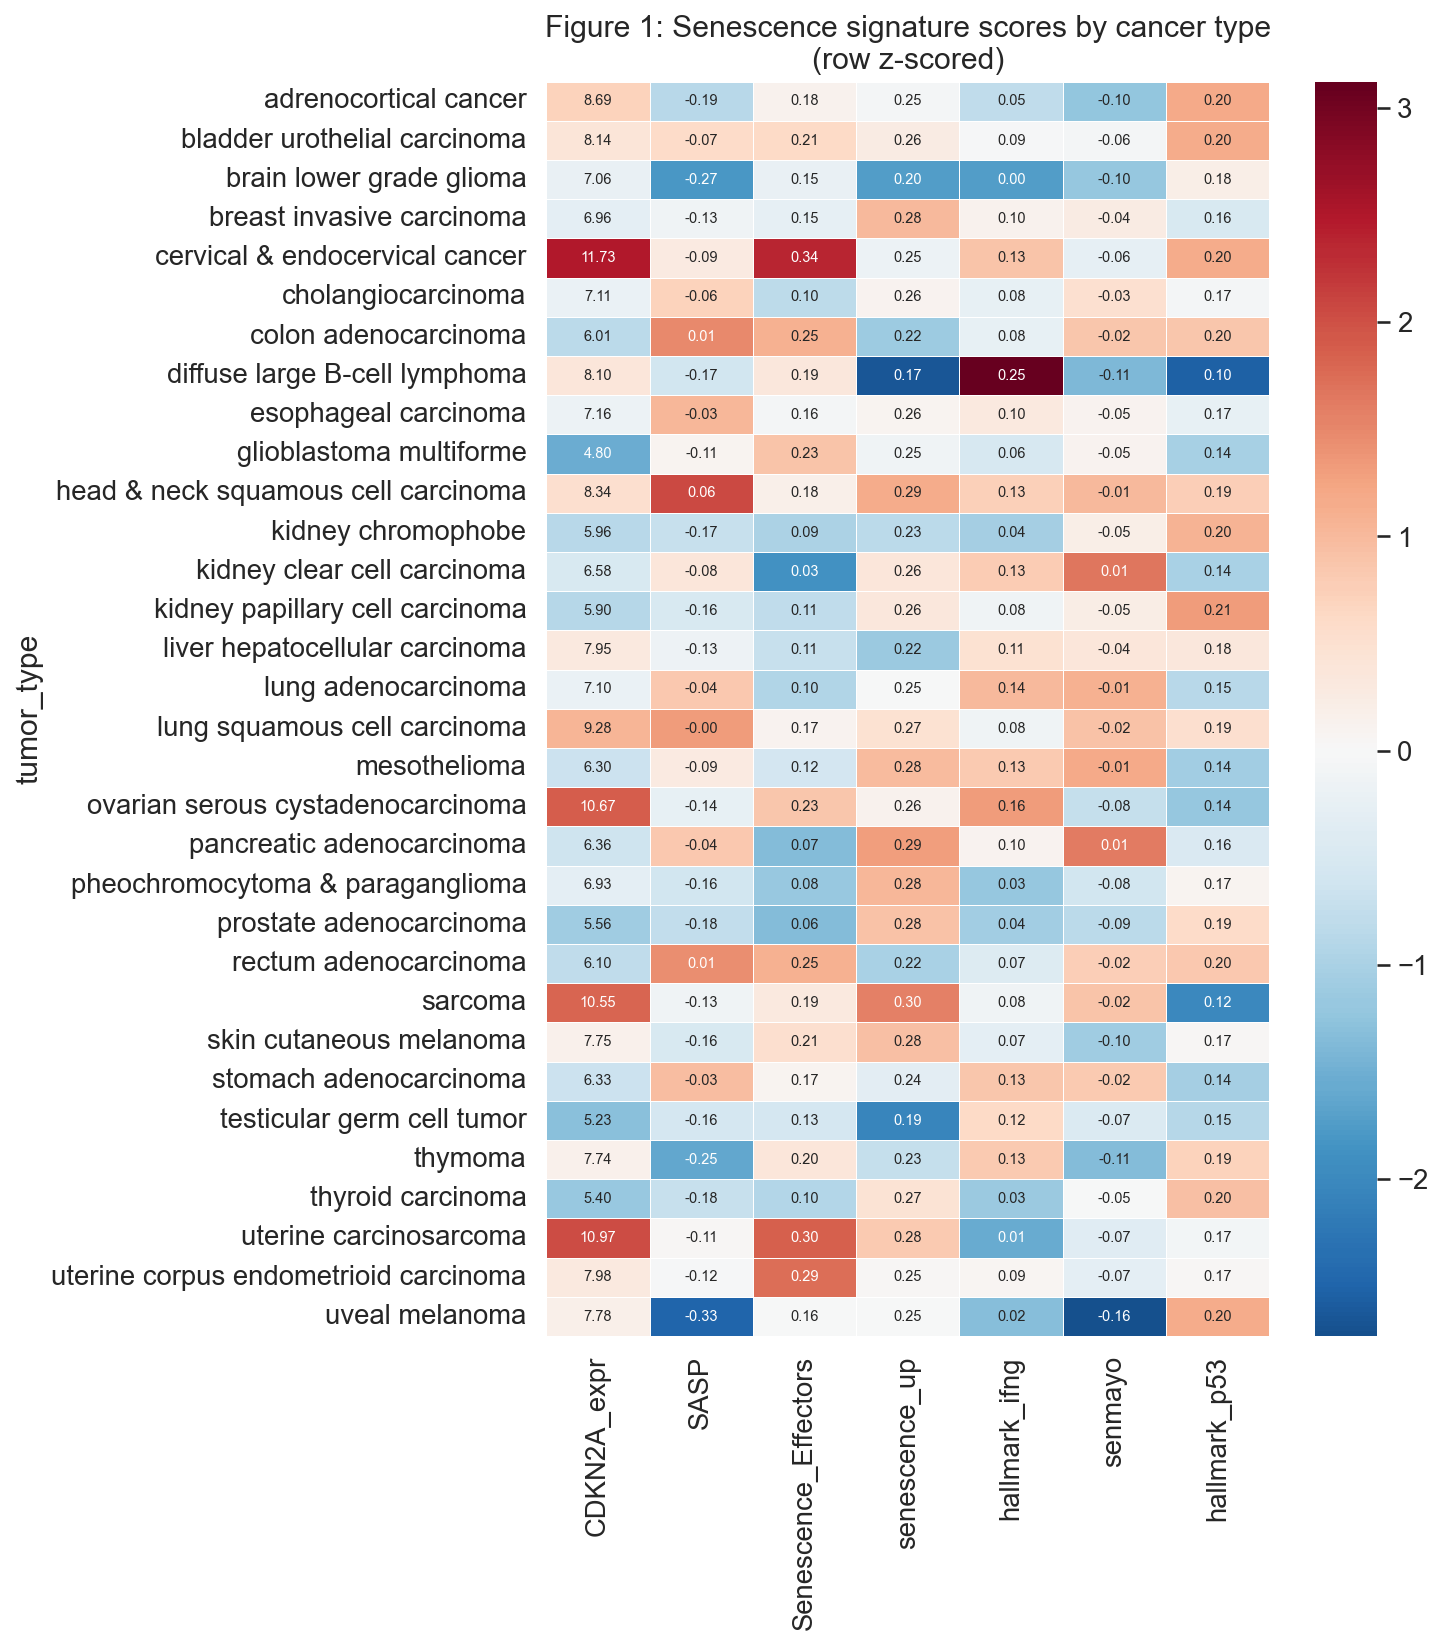

In [3]:
if "tumor_type" in master.columns:
    senes_cols = [c for c in ["CDKN2A_expr", "SASP", "Senescence_Effectors",
                               "senescence_up", "hallmark_ifng",
                               "senmayo", "hallmark_p53"]
                  if c in master.columns]

    heat = master.groupby("tumor_type")[senes_cols].median()
    heat_z = (heat - heat.mean()) / heat.std()  # z-score across tumor types

    fig, ax = plt.subplots(figsize=(10, max(6, len(heat) * 0.35)))
    sns.heatmap(heat_z, cmap="RdBu_r", center=0, linewidths=0.3,
                annot=heat.round(2), fmt=".2f", annot_kws={"size": 7}, ax=ax)
    ax.set_title("Figure 1: Senescence signature scores by cancer type\n(row z-scored)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(FIGURES / "fig1_senescence_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

## Figure 2: UMAP colored by hot/cold and CDKN2A status

Running UMAP on 9,905 samples × 5 features ...


/Users/david/miniconda3/envs/ml-genomics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


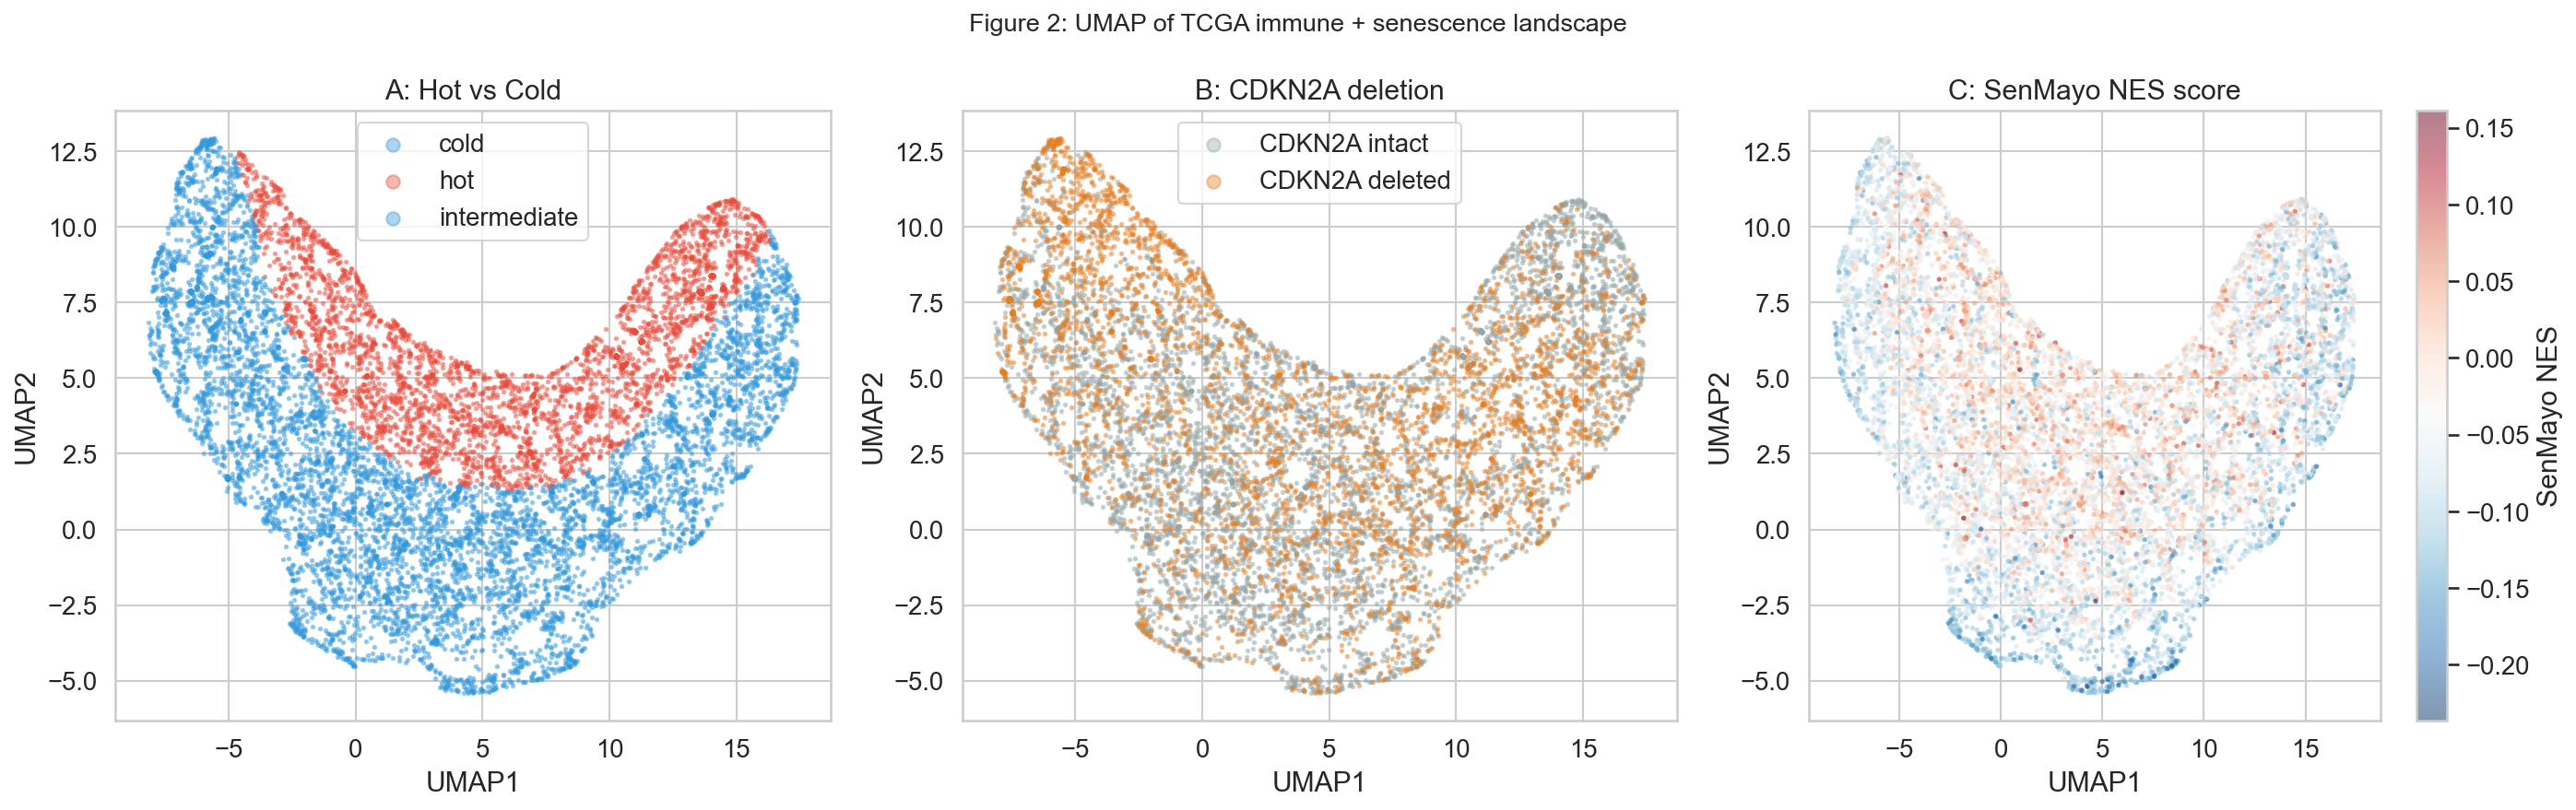

In [4]:
feature_cols = [c for c in ["ifng_score", "CDKN2A_expr", "senmayo",
                             "SASP", "cd8_fraction"]
                if c in master.columns]

umap_input = master[feature_cols].dropna()
print(f"Running UMAP on {len(umap_input):,} samples × {len(feature_cols)} features ...")

reducer = UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
embedding = reducer.fit_transform(umap_input)

umap_df = pd.DataFrame(embedding, index=umap_input.index, columns=["UMAP1", "UMAP2"])
umap_df = umap_df.join(master[["hot_cold", "cdkn2a_deleted", "senmayo"]], how="left")

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Panel A: hot/cold
for label, grp in umap_df.groupby("hot_cold"):
    axes[0].scatter(grp["UMAP1"], grp["UMAP2"], s=3, alpha=0.4,
                    c="#e74c3c" if label == "hot" else "#3498db", label=label)
axes[0].set_title("A: Hot vs Cold")
axes[0].legend(markerscale=4)

# Panel B: CDKN2A deletion status
if "cdkn2a_deleted" in umap_df.columns:
    palette = {True: "#e67e22", False: "#95a5a6"}
    for val, grp in umap_df.groupby("cdkn2a_deleted"):
        axes[1].scatter(grp["UMAP1"], grp["UMAP2"], s=3, alpha=0.4,
                        c=palette[val],
                        label="CDKN2A deleted" if val else "CDKN2A intact")
    axes[1].legend(markerscale=4)
    axes[1].set_title("B: CDKN2A deletion")

# Panel C: SenMayo NES score
if "senmayo" in umap_df.columns:
    sc = axes[2].scatter(umap_df["UMAP1"], umap_df["UMAP2"],
                         s=3, alpha=0.5,
                         c=umap_df["senmayo"],
                         cmap="RdBu_r")
    plt.colorbar(sc, ax=axes[2], label="SenMayo NES")
    axes[2].set_title("C: SenMayo NES score")

for ax in axes:
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")

fig.suptitle("Figure 2: UMAP of TCGA immune + senescence landscape", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "fig2_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: Correlation matrix — senescence × immune

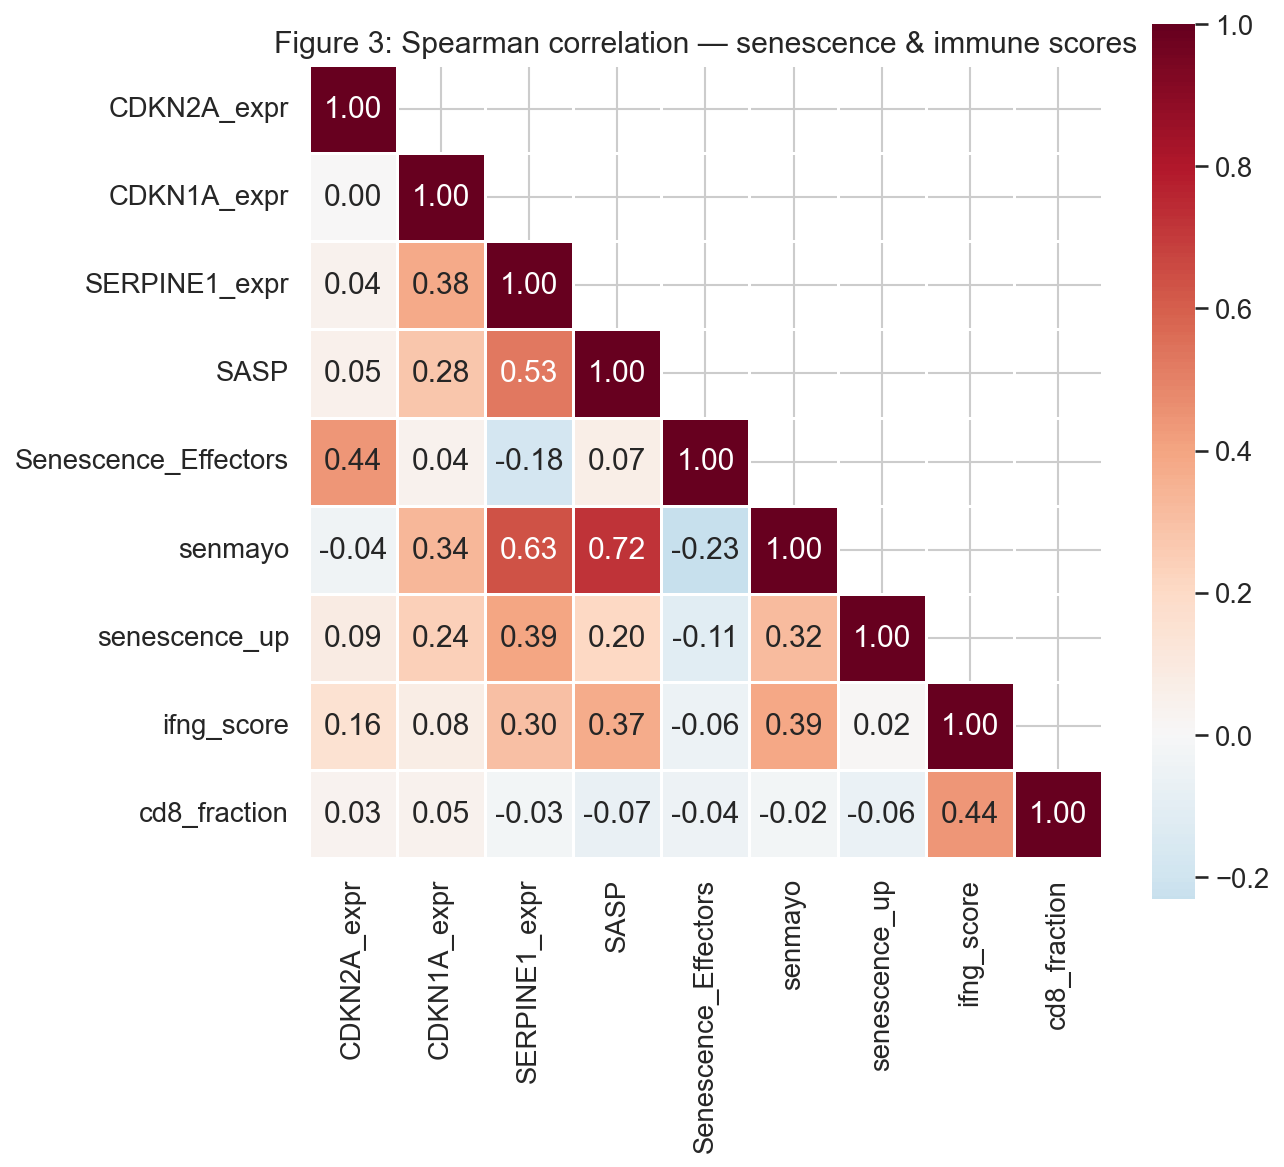

In [5]:
corr_cols = [c for c in
             ["CDKN2A_expr", "CDKN1A_expr", "SERPINE1_expr",
              "SASP", "Senescence_Effectors", "senmayo",
              "senescence_up", "ifng_score", "cd8_fraction"]
             if c in master.columns]

corr_matrix = master[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Figure 3: Spearman correlation — senescence & immune scores")
plt.tight_layout()
plt.savefig(FIGURES / "fig3_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4: Survival curves (references notebook 05 outputs)

## Figure 5: p16/CDKN2A pathway diagram

In [6]:
from pathway_diagram import render_to_png

pathway_png = FIGURES / "p16_pathway.png"
try:
    render_to_png(pathway_png)
    from IPython.display import Image as IPImage, display
    display(IPImage(str(pathway_png), width=900))
except Exception as e:
    print(f"Could not render pathway PNG (needs network): {e}")
    print("The diagram will still render live in the Streamlit app via Mermaid.js CDN.")

Could not render pathway PNG (needs network): 414 Client Error: URI Too Long for url: https://mermaid.ink/img/eyJjb2RlIjogImZsb3djaGFydCBURFxuXG4gICAgJSUgXHUyNTAwXHUyNTAwIFVwc3RyZWFtIGluZHVjZXJzIFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFx1MjUwMFxuICAgIE9OQ1tcIk9uY29nZW5pYyBhY3RpdmF0aW9uPGJyLz5SQVMgXHUwMGI3IE1ZQyBcdTAwYjcgQlJBRlwiXVxuICAgIEROQURNR1tcIkROQSBkYW1hZ2U8YnIvPlJlcGxpY2F0aW9uIHN0cmVzcyBcdTAwYjcgSVJcIl1cbiAgICBUR0ZCW1wiVEdGLVx1MDNiMiBzaWduYWxsaW5nXCJdXG5cbiAgICAlJSBcdTI1MDBcdTI1MDAgU2Vuc29yIC8gYWRhcHRvciBsYXllciBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdTI1MDBcdT

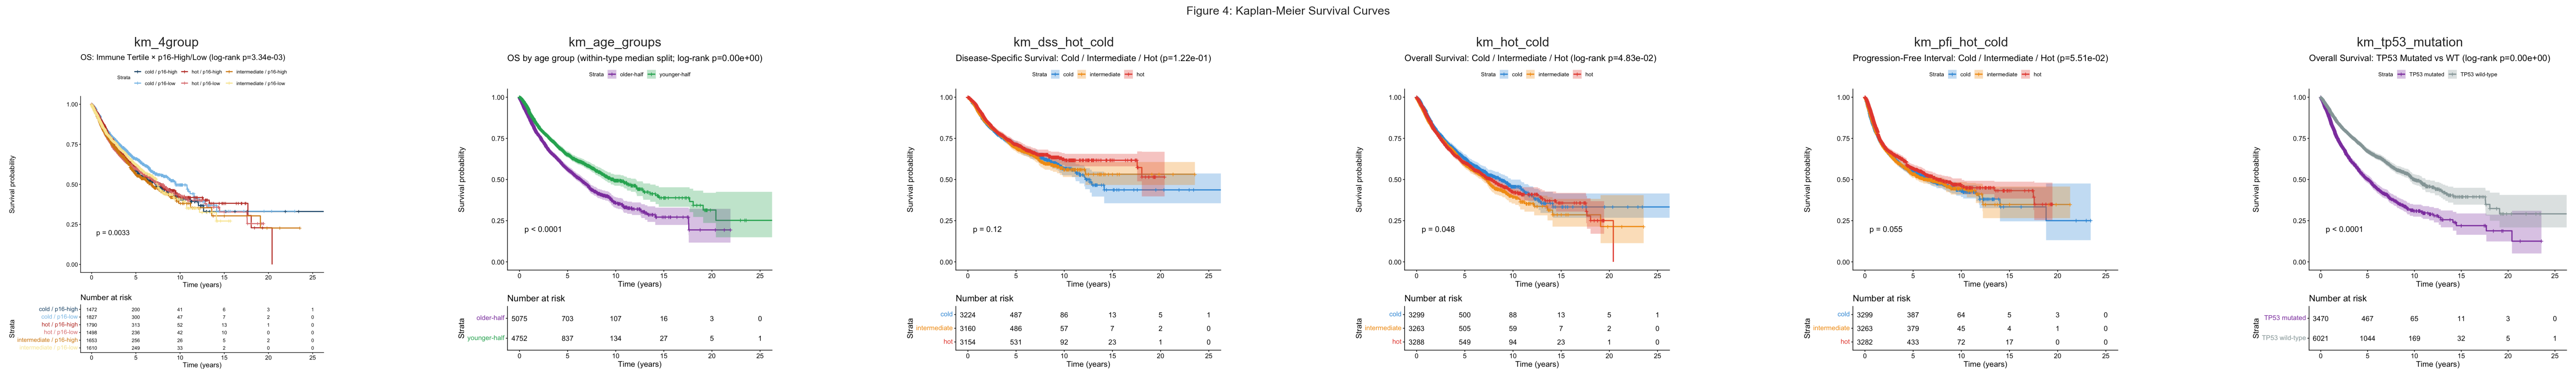

In [7]:
import glob
km_files = sorted(FIGURES.glob("km_*.png"))
if km_files:
    from PIL import Image
    imgs = [Image.open(f) for f in km_files]
    fig, axes = plt.subplots(1, len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    for ax, img, f in zip(axes, imgs, km_files):
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f.stem)
    fig.suptitle("Figure 4: Kaplan-Meier Survival Curves", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / "fig4_survival_composite.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run notebook 05 first to generate KM plots.")